In [3]:
import os

# Create results folder
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"✅ Results folder ready: {RESULTS_DIR}")

✅ Results folder ready: c:\Users\HP\ecocharge\results


In [4]:
import sys, os

# Fix path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")

for p in [SRC_DIR, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"✅ SRC: {SRC_DIR}")
print(f"✅ ROOT: {PROJECT_ROOT}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load NASA dataset CSV
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "battery_data.csv")

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded NASA dataset: {df.shape}")
    print(df.head())
else:
    print("❌ battery_data.csv not found!")
    print("Run: cd src && python download_data.py")

plt.style.use("dark_background")
sns.set_palette("Set2")
print("✅ Ready!")


✅ SRC: c:\Users\HP\ecocharge\src
✅ ROOT: c:\Users\HP\ecocharge
✅ Loaded NASA dataset: (636, 9)
  battery_id  cycle  voltage_measured  current_measured  temperature_measured  \
0      B0005      1            3.5298           -1.8187               32.5723   
1      B0005      2            3.5373           -1.8176               32.7252   
2      B0005      3            3.5437           -1.8165               32.6429   
3      B0005      4            3.5437           -1.8256               32.5149   
4      B0005      5            3.5423           -1.8261               32.3823   

   current_charge  voltage_charge     time  capacity  
0             0.0             0.0  3690.23  1.856487  
1             0.0             0.0  3672.34  1.846327  
2             0.0             0.0  3651.64  1.835349  
3             0.0             0.0  3631.56  1.835263  
4             0.0             0.0  3629.17  1.834646  
✅ Ready!


Libraries loaded ✅
Dataset loaded from ../data/raw/battery_data.csv

Shape: (636, 9)
Columns: ['battery_id', 'cycle', 'voltage_measured', 'current_measured', 'temperature_measured', 'current_charge', 'voltage_charge', 'time', 'capacity']
DATASET OVERVIEW
Total records      : 636
Unique batteries   : 4
Max cycle per bat  : [168 168 168 132]
Capacity range     : 1.1538 – 2.0353 Ah
Temperature range  : 30.1 – 34.5 °C

Missing values:
battery_id              0
cycle                   0
voltage_measured        0
current_measured        0
temperature_measured    0
current_charge          0
voltage_charge          0
time                    0
capacity                0
dtype: int64


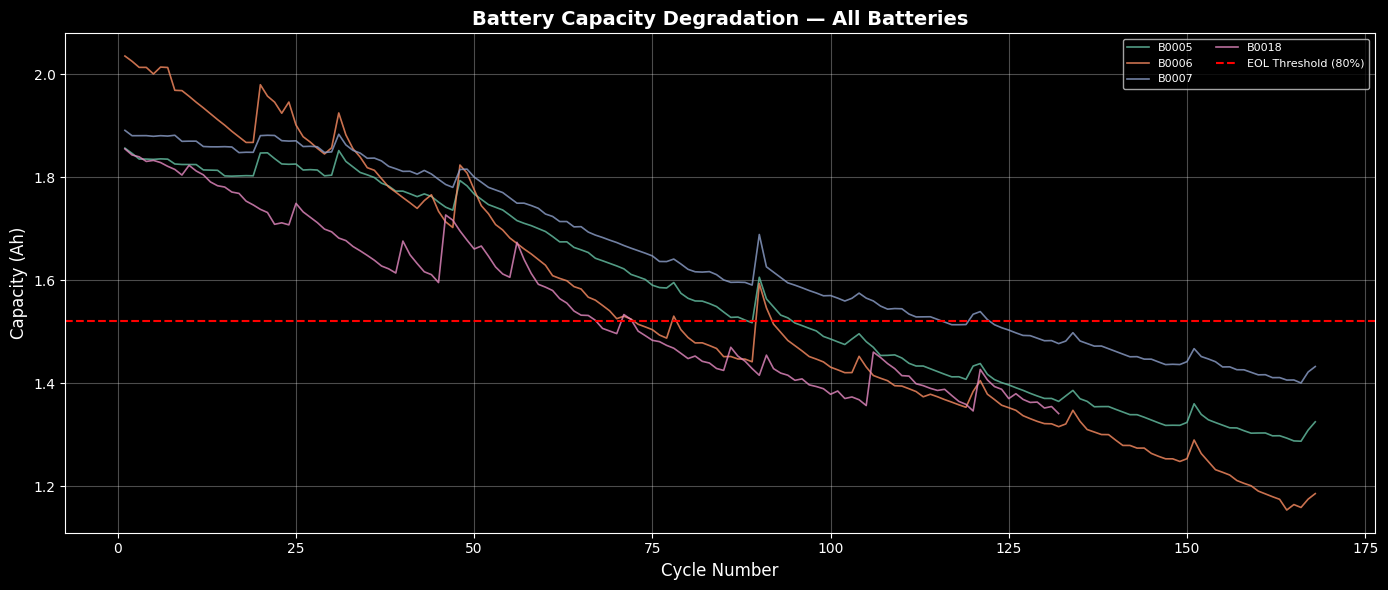

✅ Saved eda_degradation_all.png


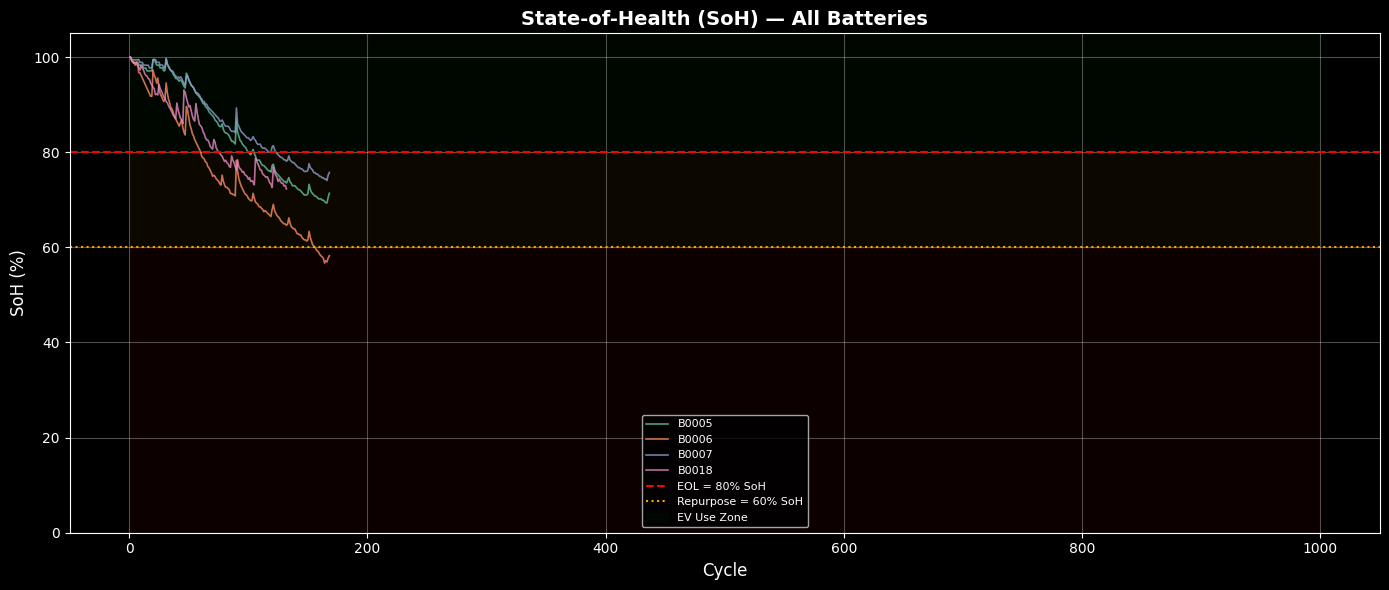

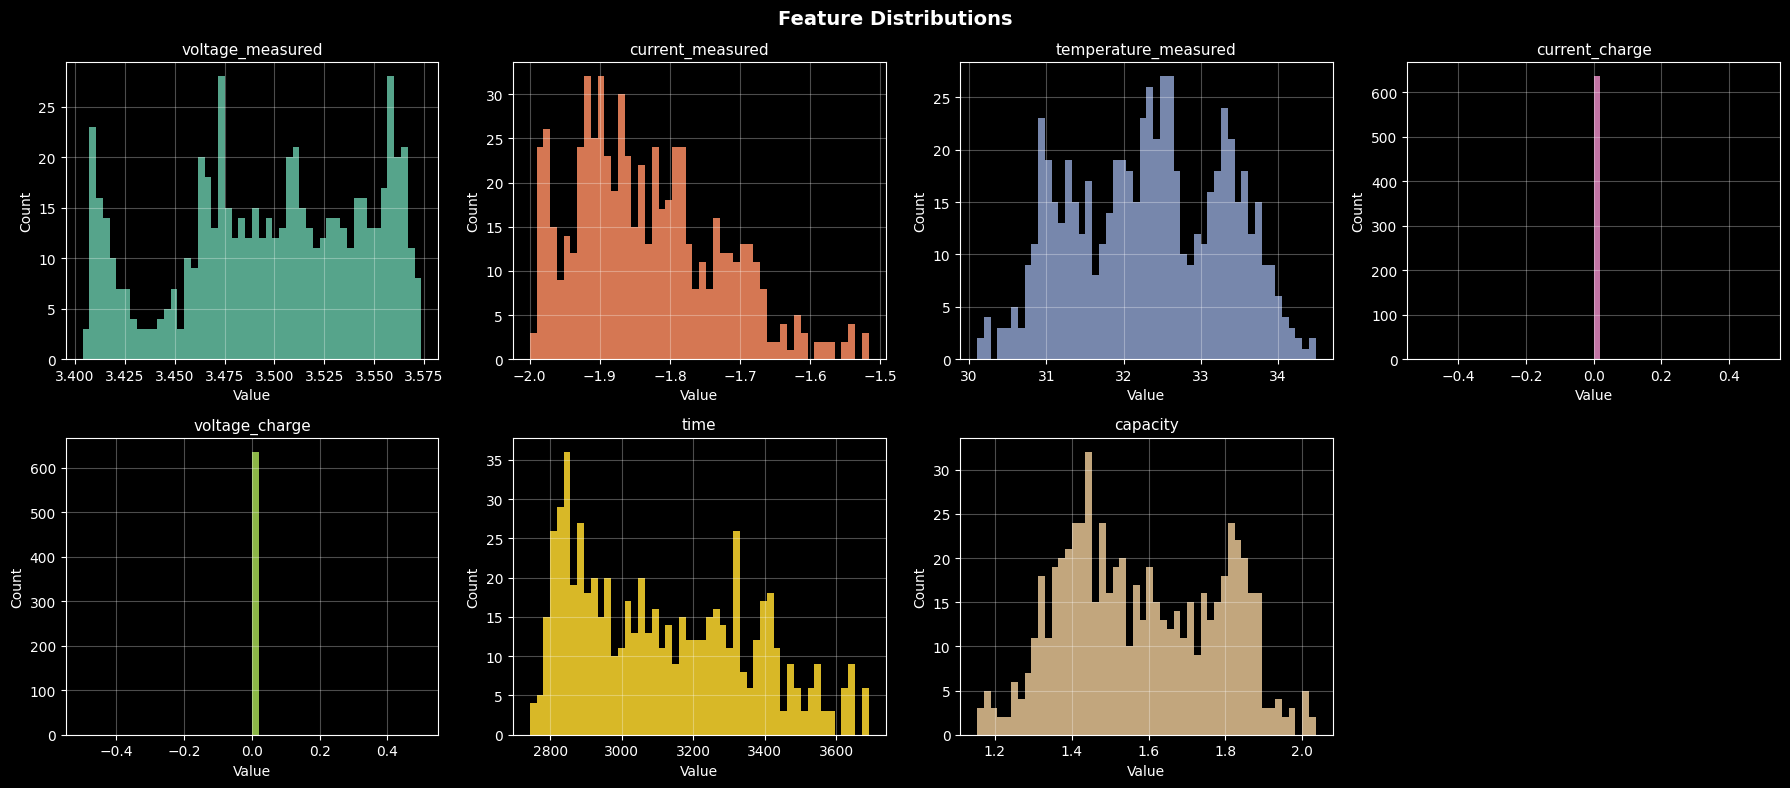

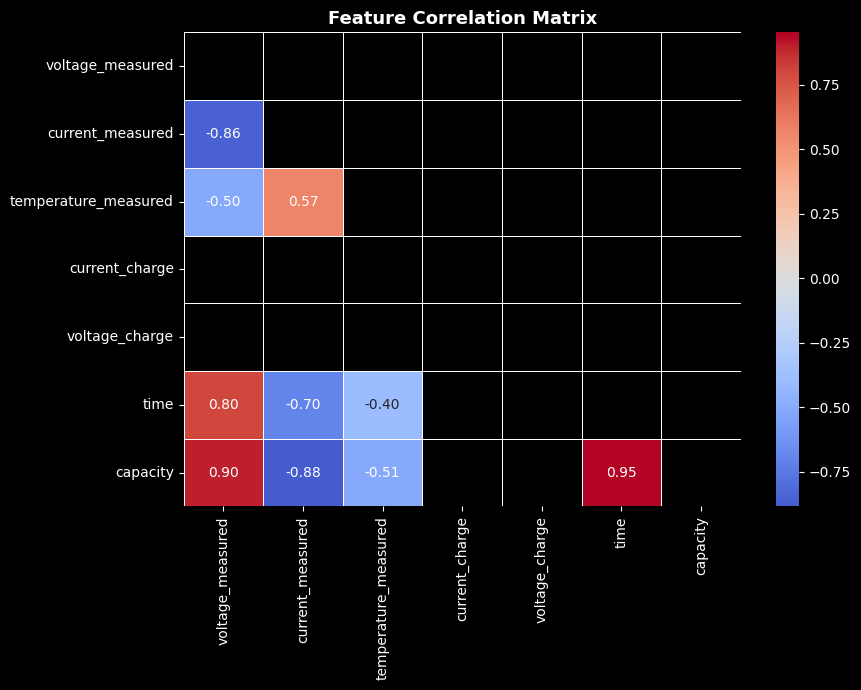

Key insight: capacity is strongly correlated with voltage and time.


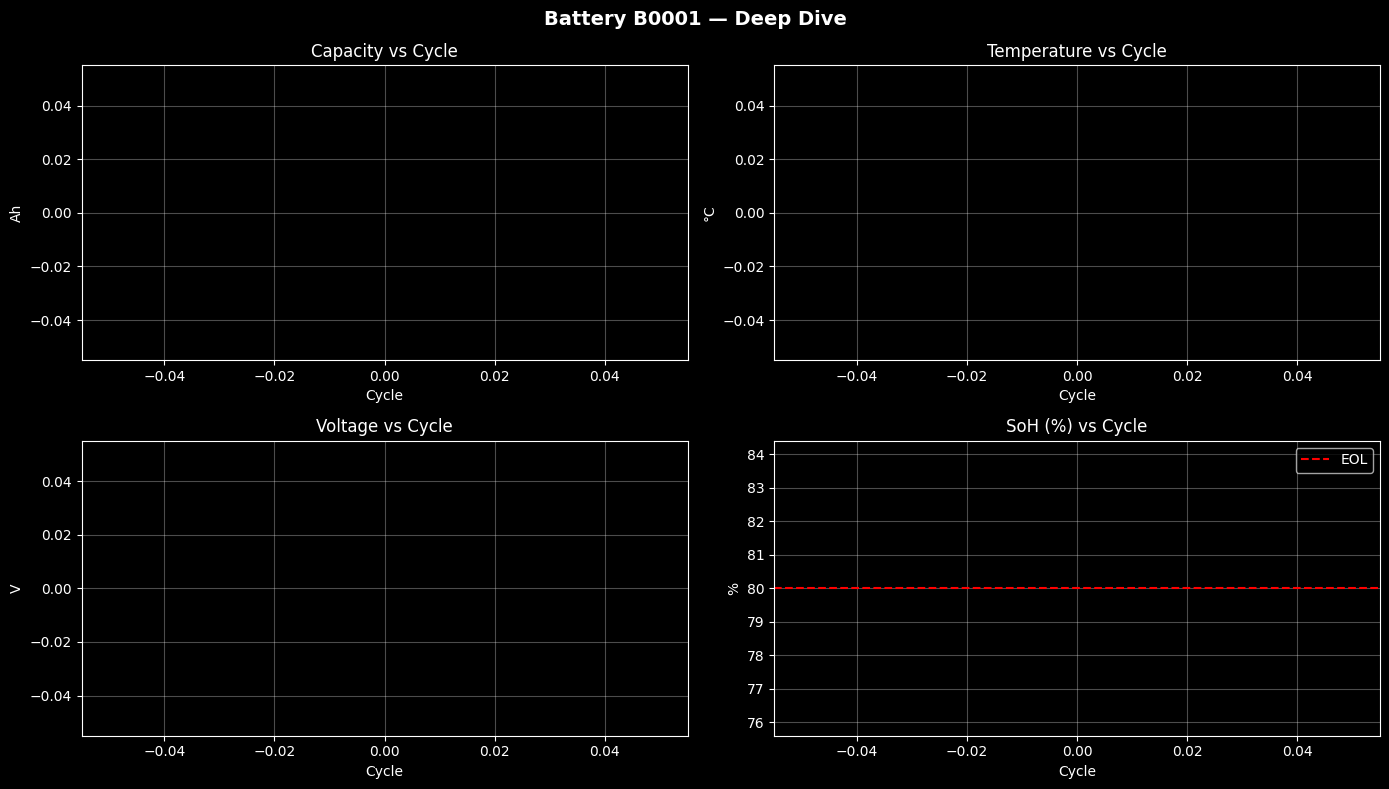

✅ EDA complete! All plots saved to /results/
   Proceed to: notebooks/02_preprocessing.ipynb


In [5]:

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Generate dataset if not present
from download_data import generate_synthetic_battery_data

plt.style.use('dark_background')
sns.set_palette("Set2")
print("Libraries loaded ✅")

# %% [markdown]
# ## 2. Load Dataset

# %%
DATA_PATH = '../data/raw/battery_data.csv'

if not os.path.exists(DATA_PATH):
    os.makedirs('../data/raw', exist_ok=True)
    df = generate_synthetic_battery_data(n_batteries=10, max_cycles=1000)
    df.to_csv(DATA_PATH, index=False)
    print(f"Dataset generated and saved → {DATA_PATH}")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded from {DATA_PATH}")

print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

# %% [markdown]
# ## 3. Basic Statistics

# %%
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total records      : {len(df):,}")
print(f"Unique batteries   : {df['battery_id'].nunique()}")
print(f"Max cycle per bat  : {df.groupby('battery_id')['cycle'].max().values}")
print(f"Capacity range     : {df['capacity'].min():.4f} – {df['capacity'].max():.4f} Ah")
print(f"Temperature range  : {df['temperature_measured'].min():.1f} – {df['temperature_measured'].max():.1f} °C")
print(f"\nMissing values:\n{df.isnull().sum()}")

# %%
df.describe().round(4)

# %% [markdown]
# ## 4. Capacity Degradation per Battery

# %%
fig, ax = plt.subplots(figsize=(14, 6))

for bid, group in df.groupby('battery_id'):
    group = group.sort_values('cycle')
    ax.plot(group['cycle'], group['capacity'], linewidth=1.2, alpha=0.8, label=bid)

ax.axhline(y=0.8 * 1.9, color='red', linestyle='--', linewidth=1.5, label='EOL Threshold (80%)')
ax.set_title('Battery Capacity Degradation — All Batteries', fontsize=14, fontweight='bold')
ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('Capacity (Ah)', fontsize=12)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/eda_degradation_all.png', dpi=150)
plt.show()
print("✅ Saved eda_degradation_all.png")

# %% [markdown]
# ## 5. State-of-Health (SoH) Calculation

# %%
df['initial_capacity'] = df.groupby('battery_id')['capacity'].transform('first')
df['soh'] = (df['capacity'] / df['initial_capacity']) * 100.0

fig, ax = plt.subplots(figsize=(14, 6))
for bid, group in df.groupby('battery_id'):
    group = group.sort_values('cycle')
    ax.plot(group['cycle'], group['soh'], linewidth=1.2, alpha=0.8, label=bid)

ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='EOL = 80% SoH')
ax.axhline(y=60, color='orange', linestyle=':', linewidth=1.5, label='Repurpose = 60% SoH')
ax.fill_between(range(1001), 80, 105, alpha=0.05, color='green', label='EV Use Zone')
ax.fill_between(range(1001), 60, 80,  alpha=0.05, color='orange')
ax.fill_between(range(1001), 0,  60,  alpha=0.05, color='red')
ax.set_title('State-of-Health (SoH) — All Batteries', fontsize=14, fontweight='bold')
ax.set_xlabel('Cycle', fontsize=12)
ax.set_ylabel('SoH (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/eda_soh_all.png', dpi=150)
plt.show()

# %% [markdown]
# ## 6. Feature Distributions

# %%
feature_cols = [
    'voltage_measured', 'current_measured', 'temperature_measured',
    'current_charge', 'voltage_charge', 'time', 'capacity'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=50, color=sns.color_palette("Set2")[i % 8],
                 edgecolor='none', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_distributions.png', dpi=150)
plt.show()

# %% [markdown]
# ## 7. Correlation Heatmap

# %%
numeric_df = df[feature_cols].copy()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_correlation.png', dpi=150)
plt.show()
print("Key insight: capacity is strongly correlated with voltage and time.")

# %% [markdown]
# ## 8. Cycle vs Capacity (One Battery Deep-Dive)

# %%
bat = df[df['battery_id'] == 'B0001'].sort_values('cycle')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(bat['cycle'], bat['capacity'], color='deepskyblue')
axes[0,0].set_title('Capacity vs Cycle'); axes[0,0].set_ylabel('Ah')

axes[0,1].plot(bat['cycle'], bat['temperature_measured'], color='tomato')
axes[0,1].set_title('Temperature vs Cycle'); axes[0,1].set_ylabel('°C')

axes[1,0].plot(bat['cycle'], bat['voltage_measured'], color='limegreen')
axes[1,0].set_title('Voltage vs Cycle'); axes[1,0].set_ylabel('V')

axes[1,1].plot(bat['cycle'], bat['soh'], color='gold')
axes[1,1].axhline(80, color='red', linestyle='--', label='EOL')
axes[1,1].set_title('SoH (%) vs Cycle'); axes[1,1].set_ylabel('%')
axes[1,1].legend()

for ax in axes.flatten():
    ax.set_xlabel('Cycle')
    ax.grid(alpha=0.3)

plt.suptitle('Battery B0001 — Deep Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_deepdive_B0001.png', dpi=150)
plt.show()

print("✅ EDA complete! All plots saved to /results/")
print("   Proceed to: notebooks/02_preprocessing.ipynb")